<a href="https://www.kaggle.com/code/lalit7881/ai-vs-real-comparison?scriptVersionId=307638612" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-41.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-48.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-25.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-45.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-20.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-4.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-38.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-46.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-26.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/an

## Import Libraries

In [2]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np

# Import specific models and their required preprocessing functions
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50V2
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as res_preprocess
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
import numpy as np
import tensorflow as tf



import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

2026-03-30 06:59:36.053274: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774853976.268627      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774853976.334198      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774853976.842322      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774853976.842385      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774853976.842388      17 computation_placer.cc:177] computation placer alr

## Loading dataset

In [3]:
DATASET_PATH = "/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 10 
SEED = 42 

In [4]:
print("Loading Data...")

train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Loading Data...
Found 995 files belonging to 2 classes.
Using 796 files for training.
Found 995 files belonging to 2 classes.
Using 199 files for validation.


2026-03-30 07:00:05.214422: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Apply augmentation only to training data
train_ds_aug = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

In [6]:
models_to_try = {
    "MobileNetV2": (MobileNetV2, mob_preprocess),
    "ResNet50V2": (ResNet50V2, res_preprocess),
    "EfficientNetB0": (EfficientNetB0, eff_preprocess)
}

results = {}

In [7]:
for model_name, (ModelClass, preprocess_fn) in models_to_try.items():

    print(f"\nTraining & Evaluating: {model_name}")

    # 1. Apply preprocessing (DON'T overwrite original datasets)
    train_data = train_ds_aug.map(
        lambda x, y: (preprocess_fn(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

    val_data = val_ds.map(
        lambda x, y: (preprocess_fn(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

    # 2. Build model
    base_model = ModelClass(
        include_top=False,
        input_shape=(224, 224, 3),
        weights="imagenet"
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    # 3. Compile
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # 4. Callbacks
    checkpoint = ModelCheckpoint(
        f"best_{model_name}.h5",
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    )

    early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    )

    # 5. Train
    model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=[checkpoint, early_stop],
        verbose=1
    )

    # 6. Evaluate
    loss, acc = model.evaluate(val_data, verbose=0)
    print(f"{model_name} Accuracy: {acc:.4f}")

    # Store results
    results[model_name] = acc


Training & Evaluating: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.7243 - loss: 0.6594

25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7280 - loss: 0.6518 - val_accuracy: 0.8945 - val_loss: 0.2718
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.9234 - loss: 0.1969

25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9236 - loss: 0.1969 - val_accuracy: 0.8995 - val_loss: 0.2305
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.9535 - loss: 0.1465

25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9534 - loss: 0.1463 - val_accuracy: 0.9196 - val_loss: 0.2138
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9657 - loss: 0.0985 - val_accuracy: 0.9196 - val_loss: 0.1903
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 954ms/step - accuracy: 0.9676 - loss: 0.0878

25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9678 - loss: 0.0874 - val_accuracy: 0.9397 - val_loss: 0.1834
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 959ms/step - accuracy: 0.9812 - loss: 0.0546

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9816 - loss: 0.0510 - val_accuracy: 0.9497 - val_loss: 0.1925
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9849 - loss: 0.0422 - val_accuracy: 0.9296 - val_loss: 0.1752
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.9791 - loss: 0.0514 - val_accuracy: 0.9246 - val_loss: 0.1686
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.9938 - loss: 0.0339 - val_accuracy: 0.9347 - val_loss: 0.2334
ResNet50V2 Accuracy: 0.9497

Training & Evaluating: EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8249 - loss: 0.4033

25/25 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.8267 - loss: 0.3998 - val_accuracy: 0.9347 - val_loss: 0.2072
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9611 - loss: 0.1215

25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9608 - loss: 0.1217 - val_accuracy: 0.9497 - val_loss: 0.1449
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9872 - loss: 0.0718

25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9870 - loss: 0.0720 - val_accuracy: 0.9648 - val_loss: 0.1110
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9834 - loss: 0.0591 - val_accuracy: 0.9598 - val_loss: 0.1116
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9827 - loss: 0.0464

25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9828 - loss: 0.0464 - val_accuracy: 0.9749 - val_loss: 0.0912
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9934 - loss: 0.0352 - val_accuracy: 0.9598 - val_loss: 0.1185
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9910 - loss: 0.0333 - val_accuracy: 0.9598 - val_loss: 0.1068
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9977 - loss: 0.0250 - val_accuracy: 0.9548 - val_loss: 0.0933
EfficientNetB0 Accuracy: 0.9749


## Accuracy 

In [8]:
for name, acc in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {acc*100:.2f}% Accuracy")

best_model_name = max(results, key=results.get)

print(f"\nThe most accurate model is {best_model_name}!")
print(f"You can now load 'best_model_{best_model_name}.h5' for your predictions.")

EfficientNetB0: 97.49% Accuracy
MobileNetV2: 94.97% Accuracy
ResNet50V2: 94.97% Accuracy

The most accurate model is EfficientNetB0!
You can now load 'best_model_EfficientNetB0.h5' for your predictions.


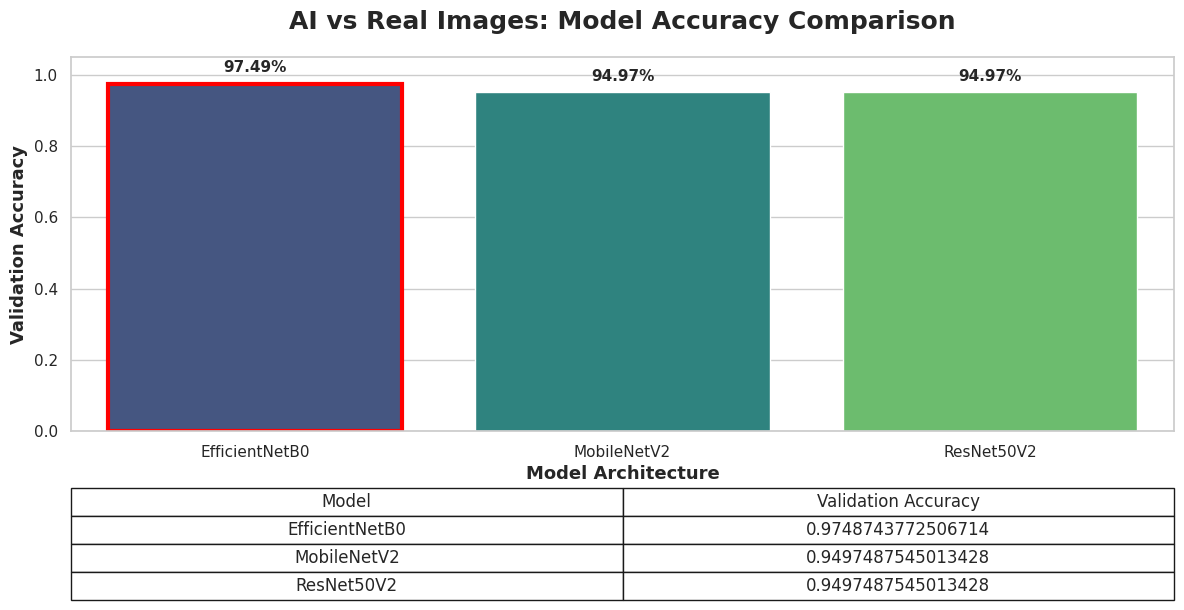

In [9]:
results_df = pd.DataFrame(list(results.items()), 
                          columns=['Model', 'Validation Accuracy'])

# Sort results
results_df = results_df.sort_values(by='Validation Accuracy', ascending=False).reset_index(drop=True)

# Theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Barplot
ax = sns.barplot(
    x='Model',
    y='Validation Accuracy',
    data=results_df,
    hue='Model',              # avoids seaborn warning
    palette="viridis",
    legend=False
)

# Titles
plt.title('AI vs Real Images: Model Accuracy Comparison',
          fontsize=18, fontweight='bold', pad=20)

plt.xlabel('Model Architecture', fontsize=13, fontweight='bold')
plt.ylabel('Validation Accuracy', fontsize=13, fontweight='bold')
plt.ylim(0, 1.05)

# Annotate bars
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.annotate(f"{height*100:.2f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                xytext=(0, 6), textcoords='offset points')

# Highlight best model (first row after sorting)
ax.patches[0].set_edgecolor('red')
ax.patches[0].set_linewidth(3)

# Optional: show small table (cleaner)
plt.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0, -0.45, 1, 0.3]
)

plt.tight_layout()

# Save
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

## Visualizations

              precision    recall  f1-score   support

AI-Generated       0.94      0.96      0.95        53
        Real       0.99      0.98      0.98       146

    accuracy                           0.97       199
   macro avg       0.97      0.97      0.97       199
weighted avg       0.98      0.97      0.97       199



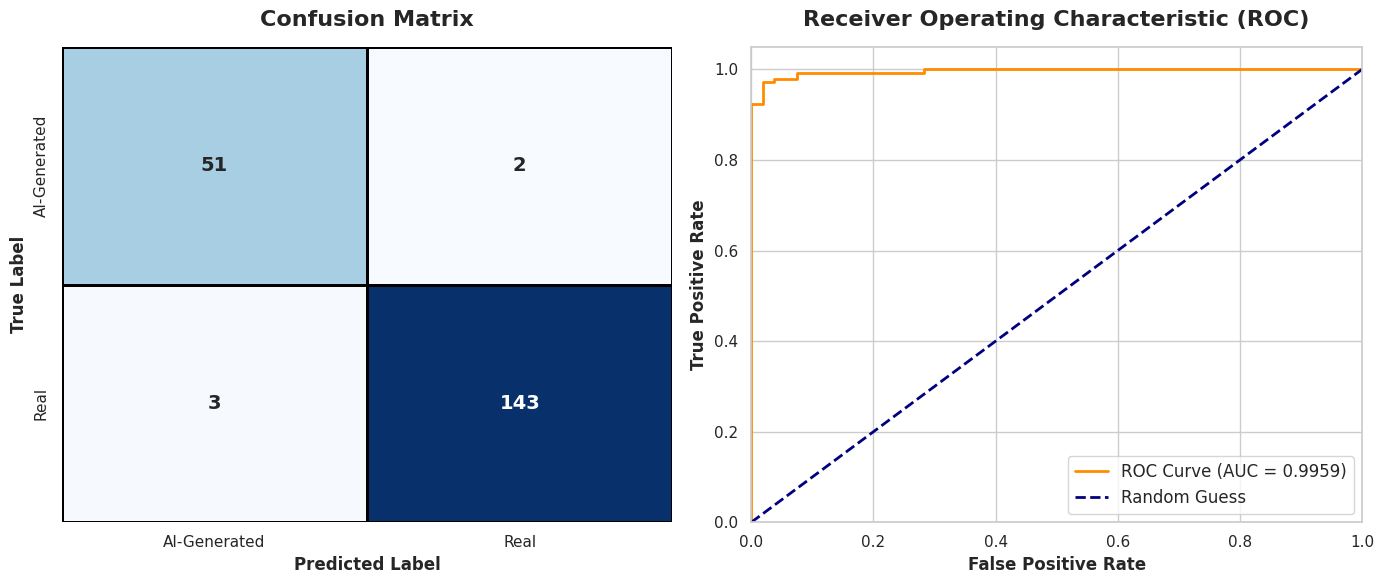

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# ---------------------------
# 1️⃣ Collect predictions
# ---------------------------
y_true, y_pred_probs = [], []

for images, labels in val_ds:  # Your preprocessed validation dataset
    y_true.extend(labels.numpy())
    y_pred_probs.extend(model.predict(images, verbose=0))

y_true = np.array(y_true).flatten()
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred_classes = (y_pred_probs > 0.5).astype(int)  # Threshold at 0.5

# ---------------------------
# 2️⃣ Class Names (manual)
# ---------------------------
class_names = ['AI-Generated', 'Real']  # <-- define manually

# ---------------------------
# 3️⃣ Classification Report
# ---------------------------
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# ---------------------------
# 4️⃣ Plot Confusion Matrix & ROC
# ---------------------------
plt.figure(figsize=(14, 6))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14, "weight": "bold"},
            linewidths=1, linecolor='black')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')

# ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.savefig('academic_evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()